Optimierungsmodel:

Wir nehmen ein price-taker Model an, bei dem der (Ver-) Kaufspreis von außen vorgegeben wird. Ziel ist es, den Erlös

$$
\sum_{i=0}^{n-1} \left[ P_{\text{entladen}}(t_i)\,\pi_{\text{verkauf}}(t_i) - P_{\text{laden}}(t_i)\,\pi_{\text{kauf}}(t_i) \right]\Delta t
$$

zu maximieren. Hierbei bezeichnet $P_{(\text{ent})laden}(t)$ die steuerbare Lade- bzw. Entladeleistung (netzseitig) und $\pi_{\text{verkauf}}$ sowie $\pi_{\text{kauf}}$ bezeichnen den von außen vorgegebenen Marktpreis für Einspeisung und Verbrauch. Mit der binären Variable $z(t_i)\in\{0,1\}$ bezeichnen wir den aktuellen Zustand des Systems. $z_i=1$ entspricht dabei "laden". Wir verbieten gleichzeitiges Laden und Entladen durch die Vorschrift

$$
0 \le P_{\text{entladen}}(t_i) \le (1 - z(t_i))\,P_{\max}
$$

$$
0 \le P_{\text{laden}}(t_i) \le z(t_i)\,P_{\max}.
$$

Den Energieinhalt des Speichers bezeichnen wir mit $E(t)$. Er folgt aus

$$
E(t_{i+1}) = E(t_i) + \bigl(P_{\text{laden}}(t_i) - P_{\text{entladen}}(t_i)\bigr)\,\Delta t.
$$

Für $E(t)$ nehmen wir die Einschränkung

$$
E_{\min} \le E(t) \le E_{\max}
$$

vor. Außerdem nehmen wir eine periodische Randbedingung $E(t_{n-1})=E({t_0})$ an.

Wir können das Problem in die Standardform eines gemischt-ganzzahligen linearen Programmes bringen. Dazu definieren wir

$$
\begin{aligned}
x_i      &= P_{\text{entladen}}(t_i),\\
x_{i+n}  &= P_{\text{laden}}(t_i),\\
x_{i+2n} &= z(t_i),\\
x_{i+3n} &= E(t_i),
\end{aligned}
$$

und

$$
\begin{aligned}
c_i      &= \pi_{\text{verkauf}}(t_i)\,\Delta t,\\
c_{i+n}  &= -\pi_{\text{kauf}}(t_i)\,\Delta t,\\
c_{i+2n} &= 0,\\
c_{i+3n} &= 0.
\end{aligned}
$$

Die Zielfunktion lautet damit $c\cdot x$.

Die Einschränkungen für Leistungsaufnahme/-abgabe können als $A x \le b$ geschrieben werden, wobei

$$
\begin{aligned}
A_{i,i}    &= 1,\\
A_{i,i+2n} &= P_{\max},\\
A_{i+n, i+n}  &= 1,\\
A_{i+n, i+2n} &= -P_{\max},
\end{aligned}
\qquad
\begin{aligned}
b_i     &= P_{\max},\\
b_{i+n} &= 0,
\end{aligned}
$$

für $\;i=0,1,\dots,n-1$.

Die Veränderung des Energieinhaltes

$$
E(t_0) = E_0,\,\qquad E(t_{n-1})=E_0
$$

$$
E(t_{i+1}) - E(t_{i}) - P_{\text{laden}}(t_i)\,\Delta t + P_{\text{entladen}}(t_i)\,\Delta t = 0
$$

schreiben wir als Nebenbedingung $A^{\text{eq}} x = b^{\text{eq}}$ mi

$$
A^{\text{eq}}_{0,3n} = 1,\qquad b^{\text{eq}}_{3n} = E_0
$$

$$
\begin{aligned}
A^{\text{eq}}_{j+1,\,3n+j+1} &= 1,\\
A^{\text{eq}}_{j+1,\,3n+j}   &= -1,\\
A^{\text{eq}}_{j+1,\,j}      &= \Delta t,\\
A^{\text{eq}}_{j+1,\,j+n}    &= -\Delta t,
\end{aligned}
\qquad
b^{\text{eq}}_{3n+1+j} = 0
$$

für $j=0,\dots,n-2$.

Den Wertebereich der Variablen können wir im Solver explizit angeben.

Bemerkungen:
* Wir nehmen an, dass die Verluste beim Laden und Entladen symmetrisch sind.
* Für identischen Kauf- und Verkaufspreis brauchen wir keine binären Variablen ==> einfaches LP. Ggf. hilfreich zum Testen.

In [20]:
import numpy as np
from scipy.optimize import milp, LinearConstraint, Bounds

def return_problem(pi_verkauf, pi_kauf, p_max, e_min, e_max, e0, i_ei, dt, eta, t_window=None):
    """BESS-Optimierungsproblem als MILP-Modell.

    Parameter
    ----------
    pi_verkauf : array_like, Länge n
        Marktpreis für Einspeisung / Verkauf pro Zeitschritt.
    pi_kauf : array_like, Länge n
        Marktpreis für Verbrauch / Einkauf pro Zeitschritt.
    p_max : float
        Maximale Lade- bzw. Entladeleistung.
    e_min : float
        Mindestenergieinhalt des Speichers.
    e_max : float
        Maximaler Energieinhalt des Speichers.
    e0 : float
        Anfangsenergieinhalt des Speichers.
    i_ei : tuple or None
        Tupel `(i, ei)`. Zum Zeitpunkt `i` soll die Energie den Wert `ei` haben.
        Wenn `None`, wird keine zusätzliche Endbedingung eingefügt.
    dt : float
        Zeitschrittweite.
    eta : float
        Lade-/Entladewirkungsgrad (symmetrisch).
    t_window : int, optional
        Fenstergröße für die Zeitreihe (Standard: None, d.h. gesamte Zeitreihe).
    Rückgabe
    -------
    dict
        MILP-Modell mit Schlüsseln:
        - c: Zielfunktionskoeffizienten
        - A_ub: Ungleichungsmatrix
        - b_ub: rechte Seite für Ungleichungen
        - A_eq: Gleichungsmatrix
        - b_eq: rechte Seite für Gleichungen
        - bounds: Grenzen für die Variablen
        - n: Anzahl Zeitschritte
    """

    # Anzahl Zeitschritte
    n = len(pi_kauf)

    if i_ei is not None:
        idx_ei, ei = i_ei
        idx_ei = int(idx_ei)
        if not (0 <= idx_ei < n):
            raise ValueError("i_ei index muss im Bereich [0, n-1] liegen")
    else:
        idx_ei = None
        ei = None

    # -------------------------------------------------
    # LP-Matrix (Ungleichungen)
    # -------------------------------------------------
    A = np.zeros((2 * n, 4 * n))
    b = np.zeros(2 * n)

    # Zielfunktion
    c = np.zeros(4 * n)

    # -------------------------------------------------
    # Gleichungen (Energie)
    # -------------------------------------------------
    n_eq = n + (1 if idx_ei is not None else 0)
    A_eq = np.zeros((n_eq, 4 * n))
    b_eq = np.zeros(n_eq)

    # =================================================
    # Zielfunktion
    # =================================================
    for i in range(n):
        c[i] = pi_verkauf[i] * dt                 # P_entladen
        c[i + n] = -pi_kauf[i] * dt               # P_laden
        # z und E haben Kosten 0

    # =================================================
    # Ungleichungen: Lade-/Entladebeschränkung
    # =================================================
    for i in range(n):

        # P_discharge <= (1 - z) Pmax
        A[i, i] = 1
        A[i, i + 2 * n] = p_max
        b[i] = p_max

        # P_charge <= z Pmax
        A[i + n, i + n] = 1
        A[i + n, i + 2 * n] = -p_max
        b[i + n] = 0

    # =================================================
    # Energiegleichung
    # =================================================
    # E0 constraint + Dynamik + Endbedingung
    A_eq = np.zeros((n + 1, 4 * n))
    b_eq = np.zeros(n + 1)

    # Anfangszustand
    A_eq[0, 3 * n] = 1
    b_eq[0] = e0

    # Dynamik
    for j in range(n - 1):

        # E_{j+1} - E_j
        A_eq[j + 1, 3 * n + (j + 1)] = 1
        A_eq[j + 1, 3 * n + j] = -1

        # + P_discharge * dt / eta
        A_eq[j + 1, j] = dt / eta

        # - P_charge * dt * eta
        A_eq[j + 1, j + n] = -dt * eta

        b_eq[j + 1] = 0

    if idx_ei is not None:
        A_eq[n, 3 * n + idx_ei] = 1
        b_eq[n] = ei

    # =================================================
    # Bounds (wichtig für MILP!)
    # =================================================
    bounds = []

    # P_discharge
    for i in range(n):
        bounds.append((0, p_max))

    # P_charge
    for i in range(n):
        bounds.append((0, p_max))

    # binary z
    for i in range(n):
        bounds.append((0, 1))

    # Energy
    for i in range(n):
        bounds.append((e_min, e_max))

    # =================================================
    # Ergebnis
    # =================================================
    return {
        "c": c,
        "A_ub": A,
        "b_ub": b,
        "A_eq": A_eq,
        "b_eq": b_eq,
        "bounds": bounds,
        "n": n,
        "t_window": t_window
    }


def solve_bess_milp(problem):
    """Löst das MILP-Problem für das BESS.

    Parameter
    ----------
    problem : dict
        MILP-Modell, wie von `return_problem` zurückgegeben:
        - c: Zielfunktionskoeffizienten
        - A_ub: Ungleichungsmatrix
        - b_ub: rechte Seite für Ungleichungen
        - A_eq: Gleichungsmatrix
        - b_eq: rechte Seite für Gleichungen
        - bounds: Grenzen der Variablen
        - n: Anzahl der Zeitschritte
        - t_window: Fenstergröße für die Zeitreihe

    Rückgabe
    -------
    dict
        Lösung mit folgenden Einträgen:
        - success: bool, ob der Solver erfolgreich war
        - objective: float, Zielfunktionswert
        - P_discharge: array, Entladeleistung
        - P_charge: array, Ladeleistung
        - z: array, binäre Lade-/Entlade-Zustände
        - E: array, Energieinhalt des Speichers
    """

    c = problem["c"]
    A_ub = problem["A_ub"]
    b_ub = problem["b_ub"]
    A_eq = problem["A_eq"]
    b_eq = problem["b_eq"]
    bounds = problem["bounds"]
    n = problem["n"]
    t_window = problem.get("t_window", None)

    # =====================================================
    # 1. Bounds
    # =====================================================
    lb = np.array([b[0] for b in bounds])
    ub = np.array([b[1] for b in bounds])

    var_bounds = Bounds(lb, ub)
    
    # =====================================================
    # 2. Constraints
    # =====================================================

    constraints = []

    # Inequality: A_ub x <= b_ub
    if A_ub is not None and len(A_ub) > 0:
        constraints.append(
            LinearConstraint(A_ub, -np.inf * np.ones_like(b_ub), b_ub)
        )

    # Equality: A_eq x = b_eq
    if A_eq is not None and len(A_eq) > 0:
        constraints.append(
            LinearConstraint(A_eq, b_eq, b_eq)
        )

    # =====================================================
    # 3. Integer variables (z = binary)
    # =====================================================
    # z sitzt bei Index 2n ... 3n-1
    integrality = np.zeros(len(c), dtype=int)
    integrality[2*n:3*n] = 1   # binär

    # =====================================================
    # 4. MILP lösen
    # =====================================================
    result = milp(
        c=-c,
        constraints=constraints,
        bounds=var_bounds,
        integrality=integrality
    )

    # =====================================================
    # 5. Ergebnis aufsplitten
    # =====================================================
    x = result.x

    P_dis = x[0:n]
    P_ch  = x[n:2*n]
    z     = x[2*n:3*n]
    E     = x[3*n:4*n]

    return {
        "success": result.success,
        "objective": -result.fun,
        "P_discharge": P_dis,
        "P_charge": P_ch,
        "z": z,
        "E": E
    }

Optimierung erfolgreich: True
Optimale Kosten: 1711.7628656159511


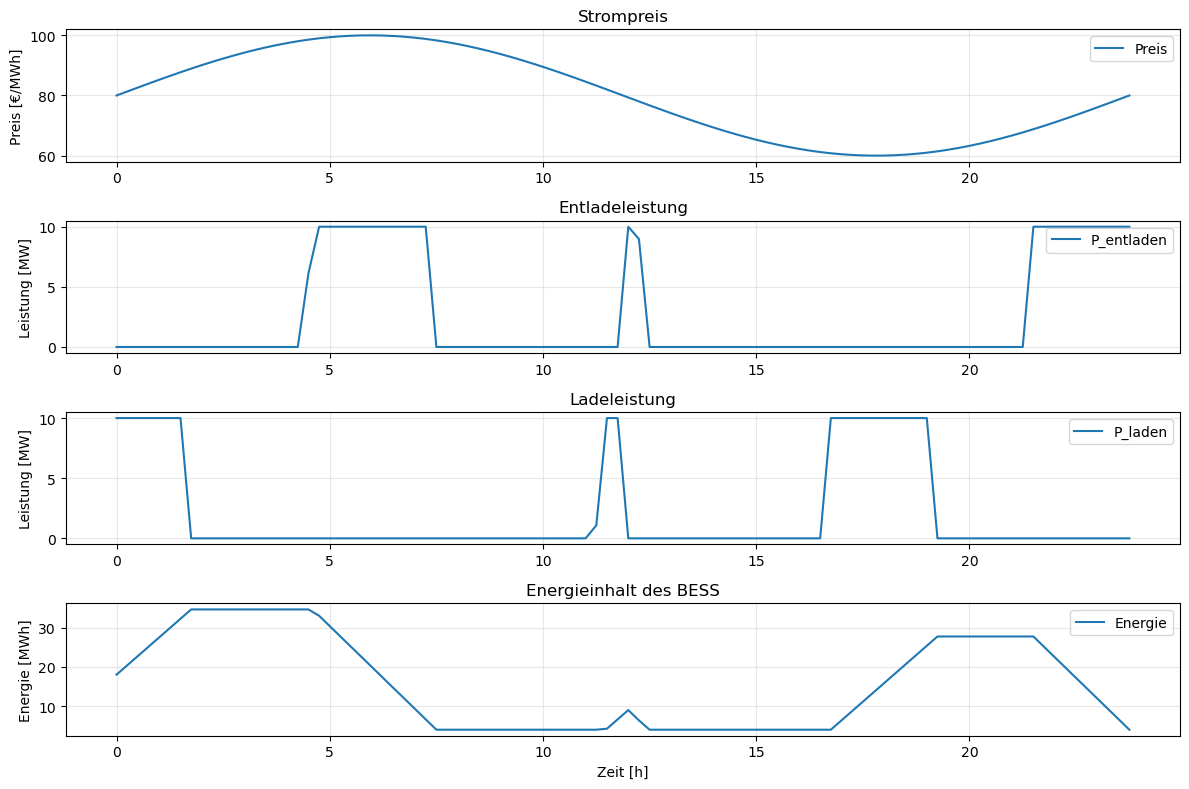

Optimale Einnahmen: 1711.76 €


In [23]:
# Beispielparameter
P_MAX = 10.0 # MW
E_MAX = 40.0 # MWh
E_MIN = 0.1 * E_MAX
E_MAX = 0.9 * E_MAX
E0    = 0.5 * E_MAX
ETA   = np.sqrt(0.9) # 90% RT-Effizienz
T     = 24 # h
N     = int(T / 0.25) # Anzahl Zeitschritte
DT    = T/N 

# Quellen:
# E_MAX = 4h * P_MAX https://www.eia.gov/todayinenergy/detail.php?id=51798&utm_source=chatgpt.com
# ca. 10-90% Ladezustand https://nenpower.com/blog/what-are-the-typical-capacities-of-commercial-battery-energy-storage-systems/?utm_source=chatgpt.com
# 85-95% RT-Effizienz https://www.surgepv.com/glossary/round-trip-efficiency?utm_source=chatgpt.com

# Sinusförmige Preiskurve
pi = 80 + 20 *np.sin(np.linspace(0, 2*np.pi, N))      # €/MWh

# Problem formulieren
problem = return_problem(pi_verkauf=pi, pi_kauf=pi, p_max=P_MAX, e_min=E_MIN, e_max=E_MAX, e0=E0, i_ei=(N-1, E0), dt=DT, eta=ETA)

# Problem lösen
result = solve_bess_milp(problem)
print("Optimierung erfolgreich:", result["success"])
print("Optimale Kosten:", result["objective"])

# Visualisierung
import matplotlib.pyplot as plt
t = np.arange(len(pi))*DT
plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(t, pi, label="Preis")
plt.ylabel("Preis [€/MWh]")
plt.title("Strompreis")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(4, 1, 2)
plt.plot(t, result["P_discharge"], label="P_entladen")
plt.ylabel("Leistung [MW]")
plt.title("Entladeleistung")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(4, 1, 3)
plt.plot(t, result["P_charge"], label="P_laden")
plt.ylabel("Leistung [MW]")
plt.title("Ladeleistung")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(4, 1, 4)
plt.plot(t, result["E"], label="Energie")
plt.ylabel("Energie [MWh]")
plt.xlabel("Zeit [h]")
plt.title("Energieinhalt des BESS")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Optimale Einnahmen: {result['objective']:.2f} €")

Beobachtung:
* Speicher wird am Ende vollständig entladen
* To-Do morgen: Rolling-Forecast

Rolling Forecast: Zu jedem Zeitpunkt wird nur ein Fenster der Zeitreihe angeschaut und die dafür optimale BESS Steuerung berechnet. Für das Ende der Zeitreihe nehmen wir periodische Randbedingungen an.

In [26]:
def get_window_prices(pi, start, window):
    """Return a cyclic window of prices for the rolling forecast.

    Parameters
    ----------
    pi : array_like
        Vollständige Preiszeitreihe.
    start : int
        Startindex des aktuellen Fensters.
    window : int
        Fenstergröße in Zeitschritten.

    Returns
    -------
    np.ndarray
        Preiswerte im aktuellen Fenster, periodisch über die Zeitreihe.
    """
    idx = np.arange(start, start + window) % len(pi)
    return pi[idx]

def solve_bess_rolling_forecast(pi_verkauf, pi_kauf, p_max, e_min, e_max, e0, e_end, dt, eta, t_window):
    """Berechnet die BESS-Steuerung über einen Rolling Forecast.

    Für jeden Zeitschritt wird ein optimales Steuerungsproblem über ein
    Fenster der Länge `t_window` gelöst. Die günstige Steuerung des ersten
    Zeitschritts des Fensters wird übernommen, danach wird das Fenster um einen
    Schritt verschoben.

    Parameters
    ----------
    pi_verkauf : array_like
        Preiszeitreihe für den Verkauf (Entladung).
    pi_kauf : array_like
        Preiszeitreihe für den Einkauf (Ladung).
    p_max : float
        Maximale Lade- bzw. Entladeleistung.
    e_min : float
        Minimaler Energieinhalt des Speichers.
    e_max : float
        Maximaler Energieinhalt des Speichers.
    e0 : float
        Anfangsenergieinhalt des Speichers.
    e_end : float
        Gewünschter Energieinhalt am Ende der Zeitreihe.
    dt : float
        Zeitschrittweite.
    eta : float
        Symmetrischer Lade-/Entladewirkungsgrad.
    t_window : int
        Fenstergröße für die Rolling-Forecast-Optimierung.

    Returns
    -------
    dict
        Ergebnisdictionary mit folgenden Einträgen:
        - P_discharge: array, Entladeleistung je Zeitschritt
        - P_charge: array, Ladeleistung je Zeitschritt
        - z: array, binäre Lade-/Entladezustände
        - E: array, Energieinhalt des Speichers (Länge n+1)
        - objective: float, kumulierter Erlös
    """
    pi_verkauf = np.asarray(pi_verkauf)
    pi_kauf = np.asarray(pi_kauf)

    if len(pi_verkauf) != len(pi_kauf):
        raise ValueError("pi_verkauf and pi_kauf must have the same length")

    n = len(pi_verkauf)
    P_dis = np.zeros(n)
    P_ch = np.zeros(n)
    z = np.zeros(n)
    E = np.zeros(n + 1)
    E[0] = e0
    current_e = e0

    for k in range(n):
        pi_window_verkauf = get_window_prices(pi_verkauf, k, t_window)
        pi_window_kauf = get_window_prices(pi_kauf, k, t_window)

        idx_ei = None
        if k <= n - 1 < k + t_window:
            idx_ei = n - 1 - k

        problem_window = return_problem(
            pi_verkauf=pi_window_verkauf,
            pi_kauf=pi_window_kauf,
            p_max=p_max,
            e_min=e_min,
            e_max=e_max,
            e0=current_e,
            i_ei=(idx_ei, e_end) if idx_ei is not None else None,
            dt=dt,
            eta=eta
        )

        result_window = solve_bess_milp(problem_window)
        if not result_window["success"]:
            raise RuntimeError(f"MILP failed at step {k}")

        P_dis[k] = result_window["P_discharge"][0]
        P_ch[k] = result_window["P_charge"][0]
        z[k] = result_window["z"][0]

        current_e = current_e - P_dis[k] * dt / eta + P_ch[k] * dt * eta
        E[k + 1] = current_e

    objective = np.sum(P_dis * pi_verkauf - P_ch * pi_kauf) * dt
    return {
        "P_discharge": P_dis,
        "P_charge": P_ch,
        "z": z,
        "E": E,
        "objective": objective
    }

In [ ]:
t.
gure(figsize=(12, 9))

plt.subplot(4, 1, 1)
plt.plot(t, pi, label="Preis")
plt.ylabel("Preis [€/MWh]")
plt.title("Strompreis")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(4, 1, 2)
plt.plot(t, rolling_result["P_discharge"], label="P_entladen")
plt.ylabel("Leistung [MW]")
plt.title("Entladeleistung (Rolling Forecast)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(4, 1, 3)
plt.plot(t, rolling_result["P_charge"], label="P_laden")
plt.ylabel("Leistung [MW]")
plt.title("Ladeleistung (Rolling Forecast)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(4, 1, 4)
plt.plot(t, rolling_result["E"][:-1], label="Energie")
plt.ylabel("Energie [MWh]")
plt.xlabel("Zeit [h]")
plt.title("Energieinhalt des BESS (Rolling Forecast)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Rolling Forecast Erlös: {rolling_result['objective']:.2f} €")
print(f"Endenergie: {rolling_result['E'][-1]:.2f} MWh")